# Study 779 — Devil-Price — for the quants 🔬

The full battery: one-sample *t* per cut, a random-**bucket** placebo, a leave-one-year-out jackknife, the decisive **non-overlapping** monthly re-run, and a seeded synthetic positive control. Everything offline once cached; fingerprint `b72f770274d9`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from devil_price import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching S&P 100 + SPY once (needs network)")
    dt.fetch()
panel, spy = dt.load_real()
events = st.build_panel_events(panel, spy)
table = st.build_sort_table(events)
print(f"panel loaded; {len(events)} weekly rebalances over {panel.shape[1]} names")


panel loaded; 976 weekly rebalances over 98 names


## 1. One-sample *t* across weekly rebalances

The unit is the per-rebalance cross-sectional spread. Note the horizon caveat: the 1-week window is (near-)non-overlapping and honest; the 1-month window is rebalanced weekly, so consecutive windows overlap ~4× and its *t* is inflated.

In [2]:
for label, col in [('devil 1wk (dm)','devil_s_dm'),('devil 1mo (dm)','devil_l_dm'),
                   ('LS 1wk','ls_s'),('LS 1mo','ls_l'),
                   ('devil vs SPY 1mo','devil_l_abn')]:
    s = st.one_sample_t(table[col].values)
    print(f'{label:<18s} n={s["n"]:4d}  mean={s["mean"]*100:+.4f}%  t={s["t"]:+.3f}')
print('\n(the +vs-SPY figure is an equal-weight-vs-cap-weight artefact, not a devil effect)')

devil 1wk (dm)     n= 976  mean=-0.0061%  t=-0.216
devil 1mo (dm)     n= 976  mean=-0.0455%  t=-0.872
LS 1wk             n= 976  mean=+0.0365%  t=+0.823
LS 1mo             n= 976  mean=+0.1827%  t=+2.281
devil vs SPY 1mo   n= 976  mean=+0.2685%  t=+3.770

(the +vs-SPY figure is an equal-weight-vs-cap-weight artefact, not a devil effect)


## 2. Random-bucket placebo — does the *devil* characteristic carry the spread?

Replace the devil sort with two random quintiles of the same size and recompute clean−devil; 20 seeds × 100 draws. If the real spread sits in the tail of that null, the characteristic (not bucket size) carried it.

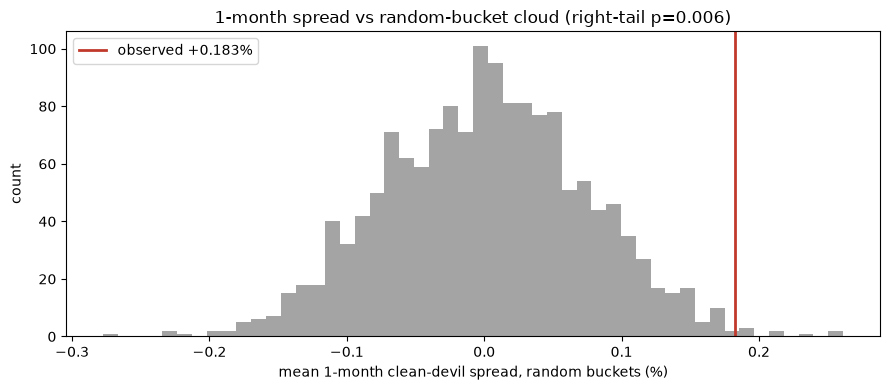

1wk placebo p = 0.178 | 1mo placebo p = 0.006


In [3]:
pl_s = st.placebo_pvalue(events, horizon='s', tail='right')
pl_l = st.placebo_pvalue(events, horizon='l', tail='right')
fig, ax = plt.subplots(figsize=(9,4))
rng = np.random.default_rng(123)
# rebuild the 1-month null cloud for the histogram
fwds = [e['fwd_l'] for e in events]; sizes=[max(1,int(round(len(f)*st.QFRAC))) for f in fwds]
cloud=[]
for _ in range(1500):
    sp=[]
    for f,k in zip(fwds,sizes):
        perm=rng.permutation(len(f)); sp.append(f[perm[k:2*k]].mean()-f[perm[:k]].mean())
    cloud.append(np.mean(sp))
ax.hist(np.array(cloud)*100, bins=50, color='#8e8e8e', alpha=0.8)
ax.axvline(pl_l['obs']*100, color='#c0392b', lw=2, label=f"observed {pl_l['obs']*100:+.3f}%")
ax.set_xlabel('mean 1-month clean-devil spread, random buckets (%)'); ax.set_ylabel('count')
ax.set_title(f"1-month spread vs random-bucket cloud (right-tail p={pl_l['p_value']:.3f})"); ax.legend()
plt.tight_layout(); plt.show()
print('1wk placebo p =', round(pl_s['p_value'],3), '| 1mo placebo p =', round(pl_l['p_value'],3))

## 3. The decisive test — de-overlap the monthly windows

Rebalance **monthly** (spacing = 21) so the 21-day windows no longer overlap. If the monthly *t* = +2.28 was real, it survives; if it was overlap inflation, it collapses.

In [4]:
ev21 = st.build_panel_events(panel, spy, fwd_s=5, fwd_l=21, spacing=21)
t21 = st.build_sort_table(ev21)
s = st.one_sample_t(t21['ls_l'].values); d = st.one_sample_t(t21['devil_l_dm'].values)
pl = st.placebo_pvalue(ev21, horizon='l', tail='right')
print(f'weekly-overlap 1mo LS:   t=+2.281  (inflated)')
print(f'NON-overlap  1mo LS:     n={s["n"]}  mean={s["mean"]*100:+.4f}%  t={s["t"]:+.3f}  placebo p={pl["p_value"]:.3f}')
print(f'NON-overlap  devil (dm):  t={d["t"]:+.3f}')
print('-> the monthly edge was window overlap, not a cross-sectional signal')

weekly-overlap 1mo LS:   t=+2.281  (inflated)
NON-overlap  1mo LS:     n=232  mean=+0.2456%  t=+1.415  placebo p=0.061
NON-overlap  devil (dm):  t=-0.505
-> the monthly edge was window overlap, not a cross-sectional signal


## 4. Leave-one-year-out jackknife — 1-week LS spread

Is the (small, positive) weekly spread broad across years, or one lucky year?

In [5]:
yrs = pd.DatetimeIndex(table['date']).year
full = st.one_sample_t(table['ls_s'].values)['t']
ts = [st.one_sample_t(table[yrs!=y]['ls_s'].values)['t'] for y in sorted(set(yrs))]
print(f'full-sample t = {full:+.3f}')
print(f'jackknife t range [{min(ts):+.3f}, {max(ts):+.3f}] over {len(ts)} leave-one-year-out draws')
print('-> persistently positive (folklore sign) but never significant')

full-sample t = +0.823
jackknife t range [+0.353, +1.960] over 20 leave-one-year-out draws
-> persistently positive (folklore sign) but never significant


## 5. Synthetic positive control — the detector works, and the null is quiet

The sort detector must stay quiet on a planted-null world and recover a planted devil-quintile underperformance monotonically.

null: mean t=-0.24 sd=0.92  |t|>=2 in 0/20 seeds
planted -1%: devil-quintile mean -0.245%  t=-5.58
planted -2%: devil-quintile mean -0.427%  t=-8.94


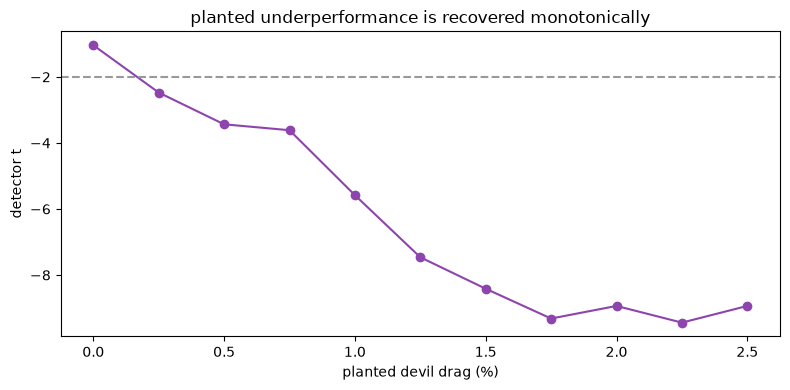

In [6]:
null_ts = np.array([st.synthetic_detect(bump=0.0, seed=789+s, side='devil')['t'] for s in range(20)])
print(f'null: mean t={null_ts.mean():+.2f} sd={null_ts.std(ddof=1):.2f}  |t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
for b in (0.01, 0.02):
    r = st.synthetic_detect(bump=b, seed=789, side='devil')
    print(f'planted -{b*100:.0f}%: devil-quintile mean {r["mean"]*100:+.3f}%  t={r["t"]:+.2f}')
bumps = np.linspace(0, 0.025, 11)
ts = [st.synthetic_detect(bump=b, seed=789, side='devil')['t'] for b in bumps]
fig, ax = plt.subplots(figsize=(8,4)); ax.plot(bumps*100, ts, 'o-', color='#8e44ad')
ax.axhline(-2, color='0.6', ls='--'); ax.set_xlabel('planted devil drag (%)'); ax.set_ylabel('detector t')
ax.set_title('planted underperformance is recovered monotonically'); plt.tight_layout(); plt.show()

## Verdict

**Signal: Weak.** The clean weekly tests are quiet (devil quintile *t* = −0.22, LS *t* = +0.82, placebo p = 0.18). There is a persistent folklore-signed lean (LS positive both horizons, hit ~54.5%, jackknife-stable positive) and the monthly spread hits placebo p = 0.006 — but that is window-overlap inflation: de-overlapped, the monthly *t* falls to +1.42 (p = 0.06). Borderline, horizon-fragile, and mechanism-free (nominal price digit ≠ fundamentals). **Tradability: Mirage.** ~18-25 bps/month gross on a weekly-turnover, ~20-a-side long/short of an arbitrary price digit — no clean significance, no mechanism, nothing to bank.